# **`ECM (Error Correction Model)`**
## **Objective**

- The objective of this study is to analyze the short-run and long-run relationship between GDP and Retail Sales using the Error Correction Model (ECM).



 1. **What is ECM**
 2. **Geometric Intuition**
 3. **Why not traditional regression**
 4. **When ECM is Useful**
 5. **When ECM Should NOT Be Used**

### **Import Libraries**

In [22]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

### **Step_01:Load Dataset**

In [23]:
df = pd.read_csv("business_cointegration_ecm_dataset.csv")

In [24]:
df.sample(10)

,Quarter,GDP_BillionPKR,Retail_Sales_BillionPKR,Advertising_Expenditure_MillionPKR,Interest_Rate_Percent,ECM_Change_in_Sales
45,2007-Q%q,560.72,532.73,278.56,7.33,-0.80
38,2005-Q%q,548.73,531.83,280.57,7.74,0.37
50,2008-Q%q,566.77,544.24,288.51,7.65,5.06
78,2015-Q%q,624.65,589.78,316.99,7.90,2.26
109,2023-Q%q,675.46,625.74,323.06,7.05,1.10
85,2017-Q%q,631.35,588.66,313.52,7.48,0.90
56,2010-Q%q,580.27,558.80,289.04,8.86,-2.45
51,2008-Q%q,567.91,543.96,280.38,8.68,1.99
88,2018-Q%q,640.36,602.77,311.10,7.72,-1.88
116,2025-Q%q,685.31,633.91,327.63,8.57,1.31


### **Step_02:Plot  Variables**

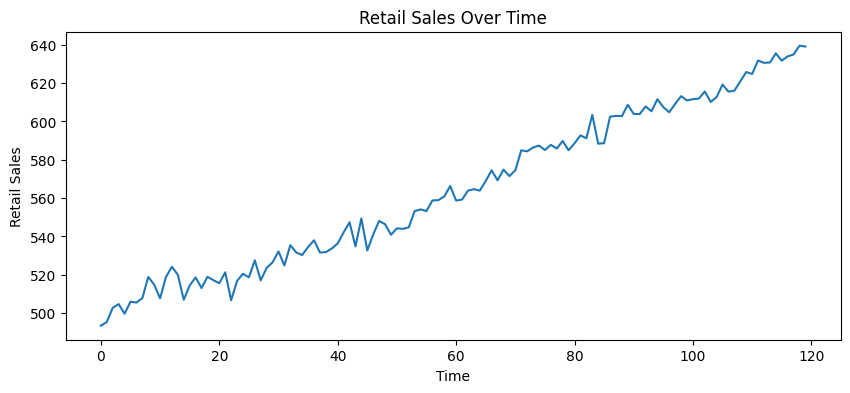

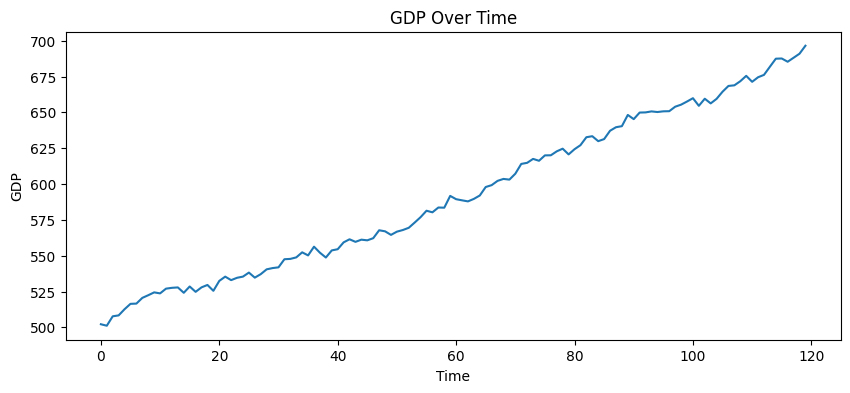

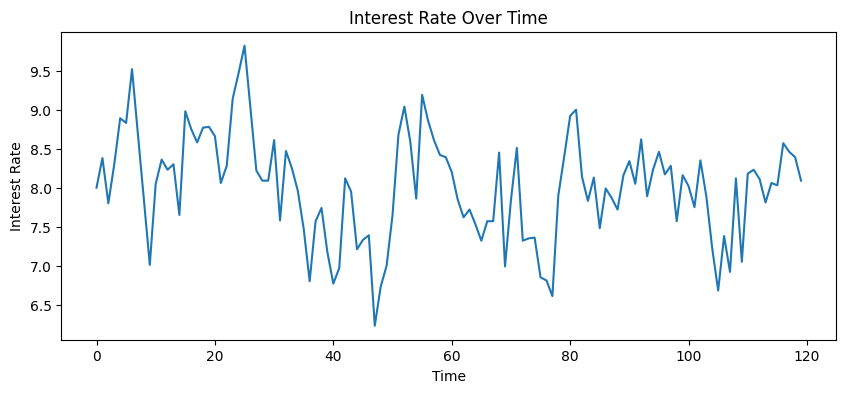

In [25]:
import matplotlib.pyplot as plt

# Plot Retail Sales
plt.figure(figsize=(10,4))
plt.plot(df['Retail_Sales_BillionPKR'])
plt.title("Retail Sales Over Time")
plt.xlabel("Time")
plt.ylabel("Retail Sales")
plt.show()

# Plot GDP
plt.figure(figsize=(10,4))
plt.plot(df['GDP_BillionPKR'])
plt.title("GDP Over Time")
plt.xlabel("Time")
plt.ylabel("GDP")
plt.show()

# Plot Interest Rate
plt.figure(figsize=(10,4))
plt.plot(df['Interest_Rate_Percent'])
plt.title("Interest Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Interest Rate")
plt.show()

### **Step_03:ADF Test**

In [26]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    
    result = adfuller(series)
    
    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("----------------------------")

# Apply ADF Test
adf_test(df['Retail_Sales_BillionPKR'], 'Retail Sales')
adf_test(df['GDP_BillionPKR'], 'GDP')
adf_test(df['Interest_Rate_Percent'], 'Interest Rate')

ADF Test for Retail Sales
ADF Statistic: 0.6357627853979032
p-value: 0.988464738727002
----------------------------
ADF Test for GDP
ADF Statistic: 1.3691665699894209
p-value: 0.9969694684982765
----------------------------
ADF Test for Interest Rate
ADF Statistic: -5.223307328720098
p-value: 7.878189249545705e-06
----------------------------


### **Step_04:First Differencing**

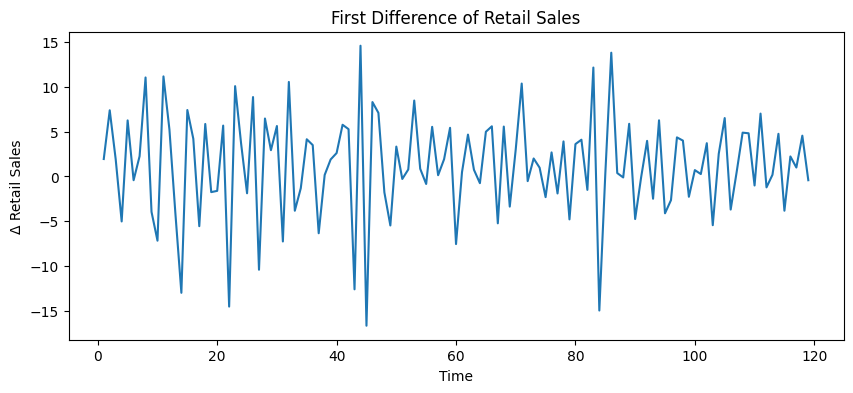

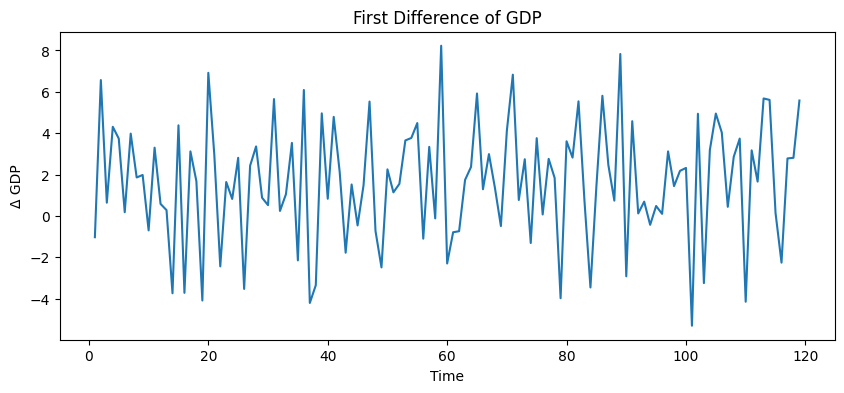

In [27]:
df['D_Retail_Sales'] = df['Retail_Sales_BillionPKR'].diff()
df['D_GDP'] = df['GDP_BillionPKR'].diff()

df_diff = df.dropna()

# Plot Differenced Retail Sales
plt.figure(figsize=(10,4))
plt.plot(df_diff['D_Retail_Sales'])
plt.title("First Difference of Retail Sales")
plt.xlabel("Time")
plt.ylabel("Δ Retail Sales")
plt.show()

# Plot Differenced GDP
plt.figure(figsize=(10,4))
plt.plot(df_diff['D_GDP'])
plt.title("First Difference of GDP")
plt.xlabel("Time")
plt.ylabel("Δ GDP")
plt.show()

- **ADF Test after differencing**

In [28]:
adf_test(df_diff['D_Retail_Sales'], 'Differenced Retail Sales')
adf_test(df_diff['D_GDP'], 'Differenced GDP')

ADF Test for Differenced Retail Sales
ADF Statistic: -7.247964693744119
p-value: 1.8112600400296352e-10
----------------------------
ADF Test for Differenced GDP
ADF Statistic: -7.314031760259109
p-value: 1.2427607438610051e-10
----------------------------


### **Step_05:Cointegration Test**

In [29]:
import pandas as pd
from statsmodels.tsa.stattools import coint

gdp = df["GDP_BillionPKR"]
retail_sales = df["Retail_Sales_BillionPKR"]

score, p_value, _ = coint(gdp, retail_sales)

print("Test Statistic:", score)
print("p-value:", p_value)

Test Statistic: -11.856060127807078
p-value: 8.135126832952783e-21


# **Step_06:Long Run Regression**

                               OLS Regression Results                              
Dep. Variable:     Retail_Sales_BillionPKR   R-squared:                       0.992
Model:                                 OLS   Adj. R-squared:                  0.992
Method:                      Least Squares   F-statistic:                 1.533e+04
Date:                     Mon, 11 May 2026   Prob (F-statistic):          9.18e-127
Time:                             06:55:28   Log-Likelihood:                -324.87
No. Observations:                      120   AIC:                             653.7
Df Residuals:                          118   BIC:                             659.3
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

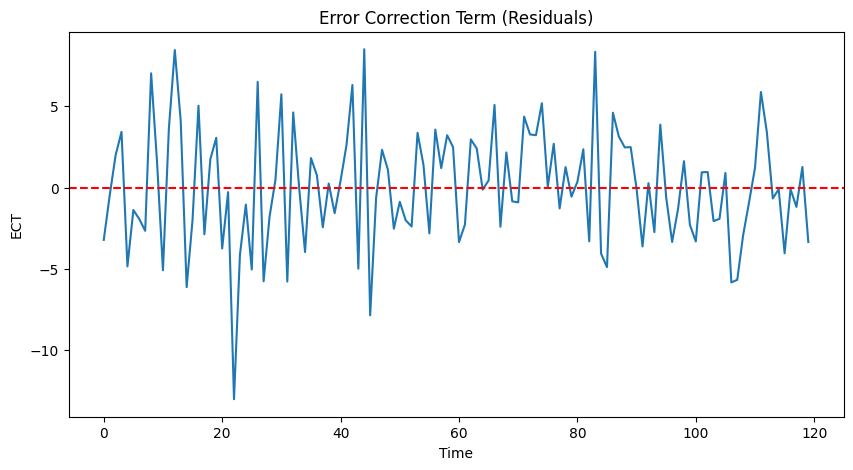

In [30]:
Y = df["Retail_Sales_BillionPKR"]
X = df["GDP_BillionPKR"]

X = sm.add_constant(X)

# Estimate long-run equation using OLS
long_run_model = sm.OLS(Y, X).fit()

# Display results
print(long_run_model.summary())

# SAVE RESIDUALS (ECT)

# Residuals from cointegration equation
df["ECT"] = long_run_model.resid

# Display first few rows
print(df[["Retail_Sales_BillionPKR",
          "GDP_BillionPKR",
          "ECT"]].head())

# PLOT RESIDUALS

plt.figure(figsize=(10,5))
plt.plot(df["ECT"])
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Error Correction Term (Residuals)")
plt.xlabel("Time")
plt.ylabel("ECT")
plt.show()

# **Step_07:Final ECM Model**

In [31]:
# Step_1
df["D_Sales"] = df["Retail_Sales_BillionPKR"].diff()

df["D_GDP"] = df["GDP_BillionPKR"].diff()

# Step_2
df["ECT_Lag1"] = df["ECT"].shift(1)

# Step_3
ecm_data = df.dropna()


# STEP 4
Y_ecm = ecm_data["D_Sales"]
X_ecm = ecm_data[["D_GDP", "Interest_Rate_Percent", "ECT_Lag1"]]

# Add intercept
X_ecm = sm.add_constant(X_ecm)

# Step_5
ecm_model = sm.OLS(Y_ecm, X_ecm).fit()
# Step_6
print(ecm_model.summary())



                            OLS Regression Results                            
Dep. Variable:                D_Sales   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     60.02
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.00e-23
Time:                        06:55:28   Log-Likelihood:                -321.51
No. Observations:                 119   AIC:                             651.0
Df Residuals:                     115   BIC:                             662.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.43